# Stage 2 Prototype: Portfolio Optimization Data Pipeline

This notebook prepares the necessary data for a QUBO-based binary portfolio optimization system. It focuses solely on data acquisition and preprocessing, providing clean artifacts for subsequent optimization steps.

---

## Section 1: Install and Import Dependencies

In [ ]:
# Install yfinance library for fetching financial data
!pip install yfinance

print("yfinance installed successfully.")

yfinance installed successfully.


In [ ]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json # For saving the sector map

print("All required libraries imported.")

All required libraries imported.


---

## Section 2: Define Stock Universe

In [ ]:
# Define the exact frozen list of 20 stocks from 4 sectors
stocks = [
    'AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', # Tech
    'JPM', 'V', 'MA', 'GS', 'BAC',         # Finance
    'LLY', 'JNJ', 'MRK', 'PFE', 'ABBV',     # Healthcare
    'XOM', 'CVX', 'GE', 'CAT', 'HON'        # Industrial/Energy
]

# Define the sector mapping dictionary
sector_map = {
    'AAPL': 'Tech',
    'MSFT': 'Tech',
    'NVDA': 'Tech',
    'GOOGL': 'Tech',
    'AMZN': 'Tech',
    'JPM': 'Finance',
    'V': 'Finance',
    'MA': 'Finance',
    'GS': 'Finance',
    'BAC': 'Finance',
    'LLY': 'Healthcare',
    'JNJ': 'Healthcare',
    'MRK': 'Healthcare',
    'PFE': 'Healthcare',
    'ABBV': 'Healthcare',
    'XOM': 'Industrial/Energy',
    'CVX': 'Industrial/Energy',
    'GE': 'Industrial/Energy',
    'CAT': 'Industrial/Energy',
    'HON': 'Industrial/Energy'
}

print(f"Defined {len(stocks)} stocks across {len(set(sector_map.values()))} sectors.")
print("Stocks list:", stocks)
print("Sector map sample:", list(sector_map.items())[:5])

Defined 20 stocks across 4 sectors.
Stocks list: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'JPM', 'V', 'MA', 'GS', 'BAC', 'LLY', 'JNJ', 'MRK', 'PFE', 'ABBV', 'XOM', 'CVX', 'GE', 'CAT', 'HON']
Sector map sample: [('AAPL', 'Tech'), ('MSFT', 'Tech'), ('NVDA', 'Tech'), ('GOOGL', 'Tech'), ('AMZN', 'Tech')]


---

## Section 3: Download One Year of Adjusted Daily Closing Prices

One year adjusted historical Daily Closing prices means basically Adjusted fixes the data by accounting for stock splits, dividends etc.

In [ ]:
# Define the date range for one year of historical data
# Set end date to yesterday to avoid issues with incomplete current day data or yfinance API quirks.
end_date = pd.Timestamp.today() - pd.Timedelta(days=1)
start_date = end_date - pd.DateOffset(years=1)

print(f"Downloading data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# Download adjusted daily closing prices using yfinance
try:
    # Download raw data first. For multiple tickers, yfinance returns a MultiIndex DataFrame.
    downloaded_data = yf.download(
    stocks,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

    if downloaded_data.empty:
        print("Error: yfinance returned an empty DataFrame. No price data available for the specified range/tickers.")
        prices_df = pd.DataFrame() # Ensure prices_df is an empty DataFrame
    else:
        prices_df = pd.DataFrame() # Initialize prices_df as empty

        # Yfinance typically returns a MultiIndex with levels (Metric, Ticker) or (Ticker, Metric)
        # and for auto_adjust=True, 'Close' contains the adjusted prices.
        if isinstance(downloaded_data.columns, pd.MultiIndex):
            # Attempt to extract 'Close' prices from the first level (Metric)
            if 'Close' in downloaded_data.columns.get_level_values(0):
                prices_df = downloaded_data.xs('Close', level=0, axis=1)
                print("Extracted 'Close' prices (adjusted) from MultiIndex level 0.")
            # Fallback to 'Adj Close' if 'Close' is not in level 0
            elif 'Adj Close' in downloaded_data.columns.get_level_values(0):
                prices_df = downloaded_data.xs('Adj Close', level=0, axis=1)
                print("Extracted 'Adj Close' prices from MultiIndex level 0 (fallback)." )
            # If the levels are reversed (Ticker, Metric)
            elif 'Close' in downloaded_data.columns.get_level_values(1):
                prices_df = downloaded_data.xs('Close', level=1, axis=1)
                print("Extracted 'Close' prices (adjusted) from MultiIndex level 1.")
            elif 'Adj Close' in downloaded_data.columns.get_level_values(1):
                prices_df = downloaded_data.xs('Adj Close', level=1, axis=1)
                print("Extracted 'Adj Close' prices from MultiIndex level 1 (fallback).")
            else:
                print("Error: Neither 'Close' nor 'Adj Close' metric found in any MultiIndex level.")
        elif 'Close' in downloaded_data.columns: # For single-level DataFrame (e.g., single ticker)
            prices_df = downloaded_data['Close']
            print("Extracted 'Close' prices (adjusted) from single-level DataFrame.")
        elif 'Adj Close' in downloaded_data.columns: # Fallback for single-level
            prices_df = downloaded_data['Adj Close']
            print("Extracted 'Adj Close' prices from single-level DataFrame (fallback).")
        else:
            print("Error: Neither 'Close' nor 'Adj Close' column found in downloaded data.")

    if not prices_df.empty:
        print("Data extraction for prices complete.")
    else:
        print("Prices DataFrame is empty after attempted extraction.")

except Exception as e:
    print(f"An unexpected error occurred during data download or price extraction: {e}")
    prices_df = pd.DataFrame() # Ensure prices_df is an empty DataFrame

# Handle missing values: drop rows with any NaN values
initial_rows = prices_df.shape[0]
if not prices_df.empty:
    prices_df.dropna(inplace=True)
    if initial_rows - prices_df.shape[0] > 0:
        print(f"Dropped {initial_rows - prices_df.shape[0]} rows with missing values.")
    else:
        print("No missing rows to drop.")
else:
    print("prices_df is empty, no missing values to handle.")

# Print shape of the dataset
print(f"Shape of prices dataset: {prices_df.shape}")

# Show the first few rows of the dataset
print("First 5 rows of adjusted closing prices:")
display(prices_df.head())

# Verify all 20 tickers downloaded successfully
if not prices_df.empty:
    missing_tickers_in_df = [ticker for ticker in stocks if ticker not in prices_df.columns]
    if not missing_tickers_in_df:
        print("All 20 tickers downloaded successfully.")
    else:
        print(f"Warning: The following tickers could not be downloaded or are missing from the prices data: {missing_tickers_in_df}")
else:
    print("prices_df is empty, cannot verify tickers as no data was downloaded.")

/tmp/ipykernel_831/1909877881.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  downloaded_data = yf.download(stocks, start=start_date, end=end_date)
[*********************100%***********************]  20 of 20 completed

Extracted 'Close' prices (adjusted) from MultiIndex level 0.
Data extraction for prices complete.
No missing rows to drop.
Shape of prices dataset: (250, 20)
First 5 rows of adjusted closing prices:


Ticker,AAPL,ABBV,AMZN,BAC,CAT,CVX,GE,GOOGL,GS,HON,JNJ,JPM,LLY,MA,MRK,MSFT,NVDA,PFE,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2025-06-02,200.902985,181.090424,206.649994,43.110355,340.979706,132.298950,246.176987,168.445923,589.491882,208.012878,151.611801,259.611084,741.872009,577.806946,73.577194,458.309204,137.347641,21.927668,362.457031,99.866631
2025-06-03,202.466782,181.342209,205.710007,43.667812,345.659027,133.940231,247.559662,165.605759,594.523132,209.165833,150.655716,261.190369,745.506348,578.552551,74.435997,459.301300,141.186722,21.824854,362.992767,100.593460
2025-06-04,202.018539,181.429367,207.229996,43.384197,345.589813,131.847839,249.559097,167.469315,589.974365,209.793030,149.484955,259.179474,760.460571,580.699951,75.526398,460.194183,141.886566,21.862240,365.115997,99.139809
2025-06-05,199.837204,181.555267,207.910004,43.403751,345.223785,131.396729,250.593597,167.628769,596.541504,209.073593,149.914230,256.952789,760.301636,582.002258,74.899178,463.973969,139.957031,21.609877,363.895660,98.684319
2025-06-06,203.114197,183.840805,213.570007,44.239952,349.566772,134.573700,254.284073,173.079849,604.536377,211.019791,151.250824,260.660706,764.472168,586.654724,76.201859,466.652588,141.686600,21.824854,367.318604,101.048943


All 20 tickers downloaded successfully.


---

## Section 4: Compute Simple Daily Returns

In [ ]:
# Compute simple daily returns using pct_change()
# Formula: r_t = (P_t - P_(t-1)) / P_(t-1)
returns_df = prices_df.pct_change()

# Drop the first row which will contain NaN values after pct_change()
returns_df.dropna(inplace=True)

# Print shape of the returns dataset
print(f"Shape of returns dataset: {returns_df.shape}")

# Show sample rows of the returns dataset
print("First 5 rows of simple daily returns:")
display(returns_df.head())

Shape of returns dataset: (249, 20)
First 5 rows of simple daily returns:


Ticker,AAPL,ABBV,AMZN,BAC,CAT,CVX,GE,GOOGL,GS,HON,JNJ,JPM,LLY,MA,MRK,MSFT,NVDA,PFE,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2025-06-03,0.007784,0.001390,-0.004549,0.012931,0.013723,0.012406,0.005617,-0.016861,0.008535,0.005543,-0.006306,0.006083,0.004899,0.001290,0.011672,0.002165,0.027952,-0.004689,0.001478,0.007278
2025-06-04,-0.002214,0.000481,0.007389,-0.006495,-0.000200,-0.015622,0.008077,0.011253,-0.007651,0.002999,-0.007771,-0.007699,0.020059,0.003712,0.014649,0.001944,0.004957,0.001713,0.005849,-0.014451
2025-06-05,-0.010798,0.000694,0.003281,0.000451,-0.001059,-0.003421,0.004145,0.000952,0.011131,-0.003429,0.002872,-0.008591,-0.000209,0.002243,-0.008305,0.008213,-0.013599,-0.011543,-0.003342,-0.004594
2025-06-06,0.016398,0.012589,0.027223,0.019266,0.012580,0.024178,0.014727,0.032519,0.013402,0.009309,0.008916,0.014430,0.005485,0.007994,0.017392,0.005773,0.012358,0.009948,0.009406,0.023961
2025-06-09,-0.012113,-0.003529,0.015967,-0.002224,0.013358,0.003922,-0.016508,0.015104,-0.000782,-0.007212,0.001290,0.003801,0.004975,-0.009812,0.004559,0.005038,0.006421,0.026552,-0.009616,0.006713


---

## Section 5: Compute Expected Return Vector μ

In [ ]:
# Compute the expected return vector (mean daily return) for each stock
mu = returns_df.mean()

# Print shape of the expected return vector
print(f"Shape of expected return vector (mu): {mu.shape}")

# Print the values of the expected return vector
print("Expected return vector (mu):")
print(mu)

# Identify and print stocks with the top 5 expected returns
print("\nTop 5 stocks by expected daily return:")
print(mu.nlargest(5))

Shape of expected return vector (mu): (20,)
Expected return vector (mu):
Ticker
AAPL     0.001866
ABBV     0.000853
AMZN     0.001259
BAC      0.000813
CAT      0.004018
CVX      0.001389
GE       0.001293
GOOGL    0.003440
GS       0.002372
HON      0.000634
JNJ      0.001648
JPM      0.000663
LLY      0.001888
MA      -0.000534
MRK      0.002065
MSFT     0.000050
NVDA     0.001952
PFE      0.000824
V       -0.000325
XOM      0.001624
dtype: float64

Top 5 stocks by expected daily return:
Ticker
CAT      0.004018
GOOGL    0.003440
GS       0.002372
MRK      0.002065
NVDA     0.001952
dtype: float64


---

## Section 6: Compute Covariance Matrix Σ

In [ ]:
# Compute the covariance matrix of daily returns
Sigma = returns_df.cov()


# Print shape of the covariance matrix
print(f"Shape of covariance matrix (Sigma): {Sigma.shape}")

# Show a sample of the covariance matrix (first 5x5 block)
print("\nSample (5x5) of the covariance matrix (Sigma):")
display(Sigma.iloc[:5, :5])

# Check for NaN values in the covariance matrix
if Sigma.isnull().any().any():
    print("Warning: Covariance matrix contains NaN values.")
else:
    print("Covariance matrix is clean (no NaN values).")

Shape of covariance matrix (Sigma): (20, 20)

Sample (5x5) of the covariance matrix (Sigma):


Ticker,AAPL,ABBV,AMZN,BAC,CAT
Ticker,,,,,
AAPL,0.000194,0.000004,0.000071,0.000064,0.000064
ABBV,0.000004,0.000228,-0.000042,-0.000001,0.000026
AMZN,0.000071,-0.000042,0.000352,0.000063,0.000072
BAC,0.000064,-0.000001,0.000063,0.000181,0.000090
CAT,0.000064,0.000026,0.000072,0.000090,0.000453


Covariance matrix is clean (no NaN values).


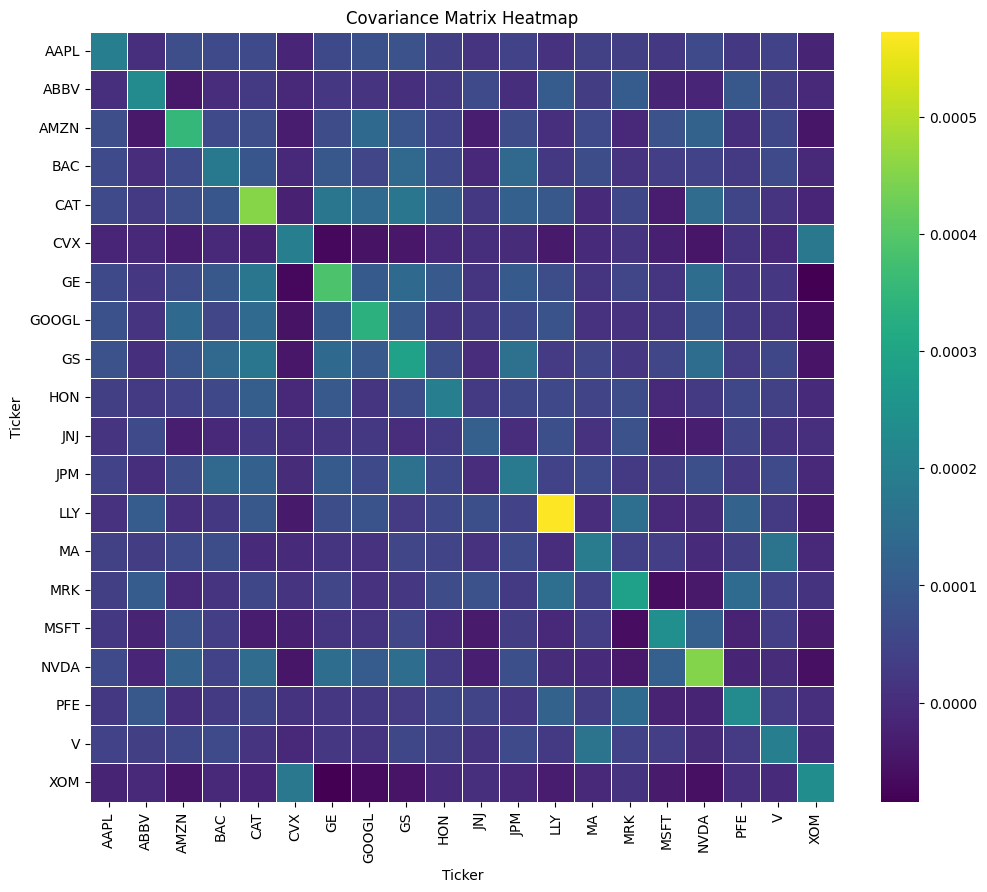

In [ ]:
# Simple heatmap visualization of the covariance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(Sigma, annot=False, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Covariance Matrix Heatmap')
plt.show()

---

## Section 7: Perform Sanity Checks

In [ ]:
# Check for missing values in final data artifacts
missing_in_prices = prices_df.isnull().sum().sum()
missing_in_returns = returns_df.isnull().sum().sum()
missing_in_mu = mu.isnull().sum()
missing_in_Sigma = Sigma.isnull().sum().sum()

if missing_in_prices == 0 and missing_in_returns == 0 and missing_in_mu == 0 and missing_in_Sigma == 0:
    print("Sanity Check 1: No missing values found in prices, returns, mu, and Sigma.")
else:
    print(f"Sanity Check 1: Warning - Missing values found! Prices: {missing_in_prices}, Returns: {missing_in_returns}, mu: {missing_in_mu}, Sigma: {missing_in_Sigma}")

# Check correct dimensions
expected_stocks = len(stocks)
expected_columns_prices = expected_stocks
expected_columns_returns = expected_stocks

if prices_df.shape[1] == expected_columns_prices and \
   returns_df.shape[1] == expected_columns_returns and \
   mu.shape[0] == expected_stocks and \
   Sigma.shape[0] == expected_stocks and Sigma.shape[1] == expected_stocks:
    print("Sanity Check 2: All data artifacts have correct dimensions.")
else:
    print(f"Sanity Check 2: Warning - Dimension mismatch! Expected {expected_stocks} stocks.")
    print(f"Prices columns: {prices_df.shape[1]}, Returns columns: {returns_df.shape[1]}, mu length: {mu.shape[0]}, Sigma shape: {Sigma.shape}")

# Sector mapping consistency check (ensure all defined stocks are in the map)
if all(stock in sector_map for stock in stocks):
    print("Sanity Check 3: All defined stocks have a sector mapping.")
else:
    print("Sanity Check 3: Warning - Some stocks are missing from the sector map.")

print("\nData pipeline successful.")

Sanity Check 1: No missing values found in prices, returns, mu, and Sigma.
Sanity Check 2: All data artifacts have correct dimensions.
Sanity Check 3: All defined stocks have a sector mapping.

Data pipeline successful.


---

## Section 8: Save Outputs for Later Notebooks

In [ ]:
# Save prices DataFrame to CSV
prices_df.to_csv('prices.csv')
print("prices.csv saved.")

# Save returns DataFrame to CSV
returns_df.to_csv('returns.csv')
print("returns.csv saved.")

# Save expected return vector (mu) to CSV
mu.to_csv('mu.csv', header=['expected_return'])
print("mu.csv saved.")

# Save covariance matrix (Sigma) to CSV
Sigma.to_csv('Sigma.csv')
print("Sigma.csv saved.")

# Save sector_map dictionary to JSON
with open('sector_map.json', 'w') as f:
    json.dump(sector_map, f, indent=4)
print("sector_map.json saved.")

print("\nAll data artifacts saved successfully.")

prices.csv saved.
returns.csv saved.
mu.csv saved.
Sigma.csv saved.
sector_map.json saved.

All data artifacts saved successfully.


In [ ]:
print("Files saved successfully.")
print("Download manually from Colab file explorer if needed.")

Files saved successfully.
Download manually from Colab file explorer if needed.


**Ticker Download Verification**

In [ ]:
missing_tickers = set(stocks) - set(prices_df.columns)

if len(missing_tickers) == 0:
    print("All 20 tickers downloaded successfully.")
else:
    print("Missing tickers:", missing_tickers)

All 20 tickers downloaded successfully.
